In [8]:
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
df = pd.read_csv("/content/NetFlix.csv.zip")

In [10]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [12]:
df=df.dropna(subset=['date_added'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7777 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7777 non-null   object
 1   type          7777 non-null   object
 2   title         7777 non-null   object
 3   director      5398 non-null   object
 4   cast          7059 non-null   object
 5   country       7271 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7777 non-null   int64 
 8   rating        7770 non-null   object
 9   duration      7777 non-null   int64 
 10  genres        7777 non-null   object
 11  description   7777 non-null   object
dtypes: int64(2), object(10)
memory usage: 789.9+ KB


In [14]:
df.describe()

,release_year,duration
count,7777.000000,7777.000000
mean,2013.935965,69.204706
std,8.760694,50.931983
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


# **DATA** **CLEANING**

In [15]:
df["show_id"]=df["show_id"].str.replace('s','')

In [16]:
df["show_id"] = df["show_id"].astype(int)

In [17]:
df["director"]=df["director"].replace('None','nan')
df["director"]=df["director"].fillna("unknown")
df["director"].isnull().sum()

np.int64(0)

In [18]:
df["cast"]=df["cast"].fillna("unkonown")
df["country"]=df["country"].fillna("unknown")


In [19]:
df["rating"]= df["rating"].fillna(df["rating"].mode()[0])
#

In [20]:
df.duplicated().sum()

np.int64(0)

#     **EDA**(Exploratory Data Analysis)

In [21]:
df["rating"].value_counts()

## INSIGHTS :
## TV-MA is the highest rated moives and TV Show

,count
rating,
TV-MA,2868
TV-14,1928
TV-PG,804
R,665
PG-13,386
TV-Y,279
TV-Y7,270
PG,247
TV-G,194


In [22]:
df[df["director"]!= "unknown"].groupby("director")["title"].count().sort_values(ascending=False).head(5)

## INSIGHTS:
 ##some directors have contributed more titles to Netflix compared to others.
 ## However, a large number of titles in the dataset have missing director information.


,title
director,
"Raúl Campos, Jan Suter",18
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12


In [23]:
df["type"].value_counts().sort_values(ascending=False)

#INSIGHTS:

# the analysis shows that the number of movies on Netflix is higher than TV shows.
#This indicates that Netflix offers more movie content compared to television series.

,count
type,
Movie,5377
TV Show,2400


In [24]:
df.groupby("release_year")["type"].value_counts()

#INSIGHTS :

#The number of titles released increased significantly after 2015,
#showing that Netflix expanded its content production in recent years.

release_year  type   
1925          TV Show      1
1942          Movie        2
1943          Movie        3
1944          Movie        3
1945          Movie        3
                        ... 
2019          TV Show    414
2020          TV Show    457
              Movie      411
2021          TV Show     19
              Movie       12
Name: count, Length: 118, dtype: int64

In [25]:
df[df["type"]=="Movie"].sort_values(by= "duration", ascending=False).head()

#INSIGHTS :
# Most movies have a  Longest runtime between 220 and 312 minutes

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
7741,958,Movie,Black Mirror: Bandersnatch,unknown,"Fionn Whitehead, Will Poulter, Craig Parkinson...",United States,28-Dec-18,2018,TV-MA,312,"Dramas, International Movies, Sci-Fi & Fantasy","In 1984, a young programmer begins to question..."
6502,6851,Movie,The School of Mischief,Houssam El-Din Mustafa,"Suhair El-Babili, Adel Emam, Saeed Saleh, Youn...",Egypt,21-May-20,1973,TV-14,253,"Comedies, Dramas, International Movies",A high school teacher volunteers to transform ...
3880,4491,Movie,No Longer kids,Samir Al Asfory,"Said Saleh, Hassan Moustafa, Ahmed Zaki, Youne...",Egypt,21-May-20,1979,TV-14,237,"Comedies, Dramas, International Movies",Hoping to prevent their father from skipping t...
2995,3695,Movie,Lock Your Girls In,Fouad El-Mohandes,"Fouad El-Mohandes, Sanaa Younes, Sherihan, Ahm...",unknown,21-May-20,1982,TV-PG,233,"Comedies, International Movies, Romantic Movies",A widower believes he must marry off his three...
4567,5109,Movie,Raya and Sakina,Hussein Kamal,"Suhair El-Babili, Shadia, Abdel Moneim Madboul...",unknown,21-May-20,1984,TV-14,230,"Comedies, Dramas, International Movies",When robberies and murders targeting women swe...


In [26]:
df[df["country"]!= "unknown"].groupby("country")["title"].count().sort_values(ascending=False).head()

#INSIGHTS:

#The United States produces the highest number of titles on Netflix.
#India and the United Kingdom are also among the top countries contributing content.

,title
country,
United States,2549
India,923
United Kingdom,396
Japan,225
South Korea,183


In [27]:
df[df["type"]=="TV Show"].groupby("type")["duration"].mean()

#Most TV Shows have average runtime  150 minutes

,duration
type,
TV Show,1.760833


In [28]:
df[df["type"]=="Movie"].groupby("type")["duration"].mean()
# INSIGHTS:
 #Most movies have a runtime between 90 and 120 minutes

,duration
type,
Movie,99.307978


# **VISUALISATION**

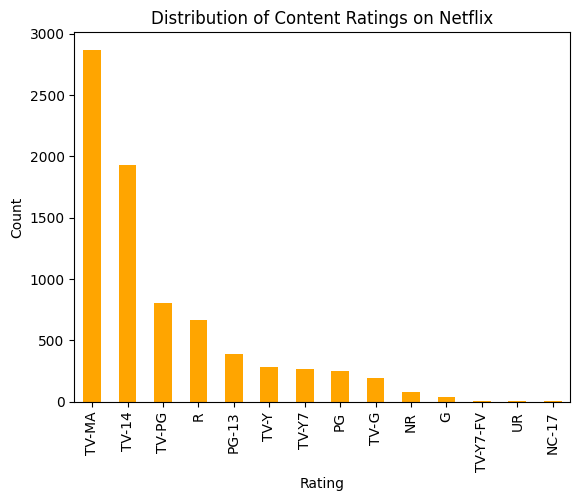

In [29]:
df["rating"].value_counts().plot(kind="bar", color="orange")

plt.title("Distribution of Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()
#Insight

#TV-MA is the most common rating in the dataset
# showing that a large portion of Netflix content is targeted toward mature audiences.

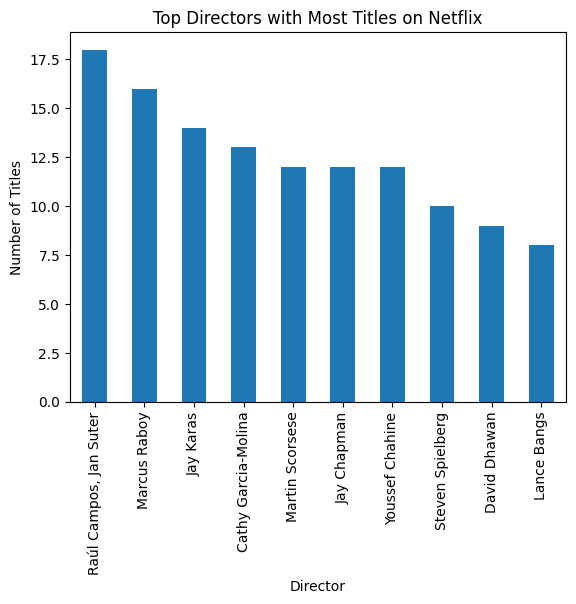

In [30]:
df[df["director"]!="unknown"].groupby("director")["title"].count().sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top Directors with Most Titles on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.show()
#INSIGHTS:
#The visualization highlights the directors who have directed the most titles available on Netflix.

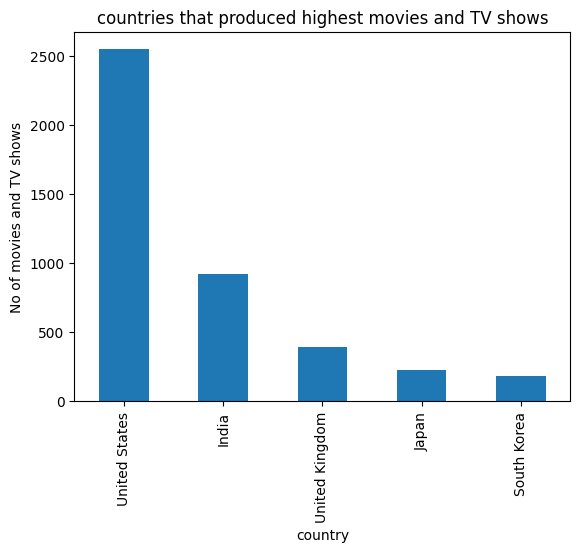

In [31]:
df[df["country"]!= "unknown"].groupby("country")["title"].count().sort_values(ascending=False).head().plot(kind="bar", )
plt.title("countries that produced highest movies and TV shows")
plt.ylabel("No of movies and TV shows")
plt.show()


#Insight

#The United States produces the highest number of Netflix titles,
# followed by India and the United Kingdom.


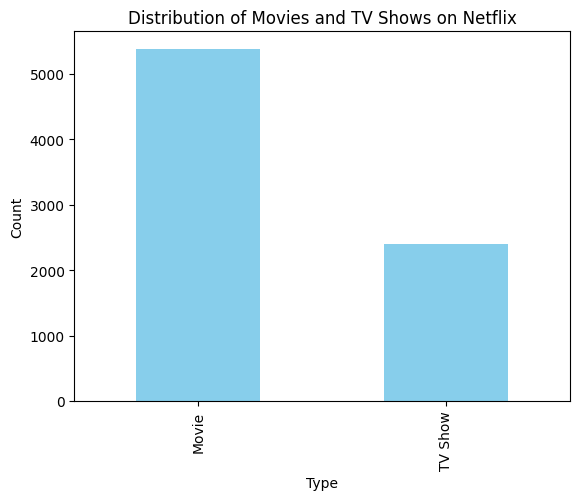

In [32]:
df["type"].value_counts().plot(kind="bar", color="skyblue")

plt.title("Distribution of Movies and TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

#Insight:

#The chart shows that movies are more common on Netflix than TV shows,
# indicating that the platform has a larger collection of films.



